# Interest Rate Modelling
### Introduction
In this project, we will analyze two common models for the short rate, namely the Hull-White and Vasicek models. We begin by estimating the parameters of each model, simulate paths of the short rate, and then use the two models to price zero-coupon bonds of varying maturities, interest rate swaps, and interest rate caps.

### Yield Curve Construction
To begin, we retrieve zero-coupon yields from the European Central Bank (ECB), calculate discount factors, interpolate these values with cubic splines to get a continuous yield curve, and then use this to calibrate the parameters of the Hull-White and Vasicek models. We interpolate the discount factors, not the yield curve, as to ensure that the discount factors are positive, and the forward rates are smooth. The yield curve used below is the ECB Euro area yield curve for AAA bonds, retrieved on Dec 15th 2025, which is a reasonable proxy for the risk-free interest rate.

In addition to the spot yield curve, we calculate the instantaneous forward rate implied by the discount-factor curve. The instantaneous forward rate $f(0,T)$ is the rate applying over an infinitesimally small period beginning at time $T$. It is related to the zero-coupon bond price by

$$f(0,T)=-\frac{\partial}{\partial T}\ln P(0,T)$$

where $P(0,T)$ is the discount factor between time $0$ and time $T$. Since we interpolate the logarithm of the discount factor using a cubic spline,

$$\ln P(0,T)\approx s(T)$$

where $s(T)$ is the cubic spline, the instantaneous forward rate can be obtained by differentiating this spline:

$$f(0,T)=-s'(T)$$

The instantaneous forward rates, along with the interpolated yield curves, are plotted below.


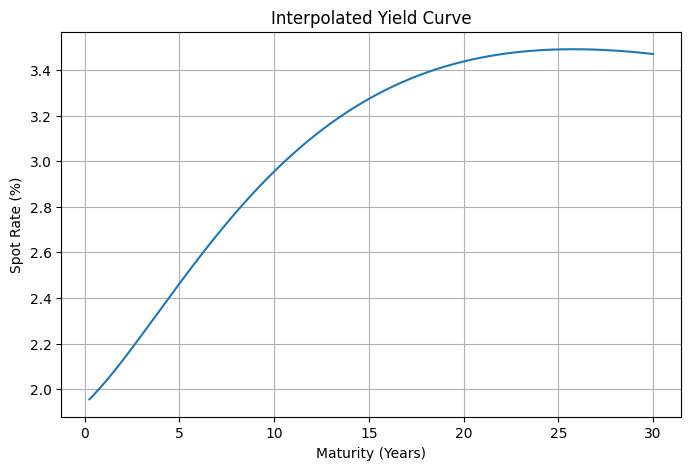

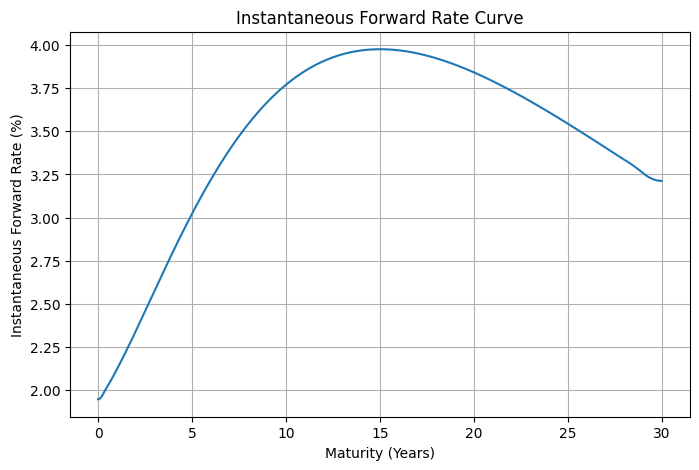

In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt


def get_yield_curve():
    url = f'https://drive.google.com/uc?id=1xSeBasdyaByJk6K2KohXQYKIUB5GIlwF&export=download'
    df = pd.read_csv(url)
    df["SPOT RATE"] = df["SPOT RATE"] / 100
    df["DISCOUNT FACTOR"] = np.exp(-df["SPOT RATE"] * df["YEARS"])
    df.loc[-1] = [0, np.nan, 1]
    df.index = df.index + 1
    df = df.sort_index().reset_index(drop=True)
    return df


def build_discount_curve(df):
    T = df["YEARS"].values
    P = df["DISCOUNT FACTOR"].values

    logP = np.log(P)
    spline_logP = CubicSpline(T, logP, bc_type="natural")

    def discount_curve(t):
        t = np.asarray(t)
        return np.exp(spline_logP(t))

    return discount_curve, spline_logP


def plot_yield_curve(discount_curve, T_min=0.25, T_max=30.0, n=500):
    T = np.linspace(T_min, T_max, n)
    P = discount_curve(T)
    y = -np.log(P) / T

    plt.figure(figsize=(8, 5))
    plt.plot(T, y*100) # *100 to convert to percent
    plt.xlabel("Maturity (Years)")
    plt.ylabel("Spot Rate (%)")
    plt.title("Interpolated Yield Curve")
    plt.grid(True)
    plt.show()

def plot_forward_rate(spline_logP, T_min=0, T_max=30.0, n=500):
    T = np.linspace(T_min, T_max, n)

    # f(0,T) = -d/dT log(P(0,T))
    forward_rate = -spline_logP.derivative(1)(T)

    plt.figure(figsize=(8, 5))
    plt.plot(T, forward_rate * 100)

    plt.xlabel("Maturity (Years)")
    plt.ylabel("Instantaneous Forward Rate (%)")
    plt.title("Instantaneous Forward Rate Curve")
    plt.grid(True)
    plt.show()

yield_curve_df = get_yield_curve()
discount_curve, spline_logP = build_discount_curve(yield_curve_df)
r0 = -spline_logP.derivative(1)(0)
plot_yield_curve(discount_curve)
plot_forward_rate(spline_logP)

### Vasicek Model
The Vasicek model of interest rates is given by:
$$
dr_t = a(b - r_t)\,dt + \sigma\,dW_t
$$

where $a > 0$, $b$ and $σ > 0$ are constants. $a$ represents the speed of mean reversion, $b$ the long-term mean, and $\sigma$ the volatility. $W_t$ is Brownian motion. The solution to this SDE is, given the interest $r_s$ at time $s < t$,

$$
r_t = r_s e^{-a(t-s)} + b\left(1 - e^{-a(t-s)}\right) + \sigma \int_{s}^{t} e^{a(u-t)} dW_u
$$

### Hull-White Model
The Hull-White model of interest rates is given by:

$$
dr_t = (\theta(t) - α r_t)\,dt + \sigma\,dW_t
$$

where $α > 0$,  $σ$ is as in the Vasicek model, and $\theta(t)$ is a function, defined by

$$
\theta(t)
= \frac{d f(0,t)}{dt}
+ α f(0,t)
+ \frac{\sigma^2}{2α}\left(1 - e^{-2αt}\right)
$$

where

$$
f(0,t) = -\frac{d}{dt} \log P(0,t)
$$

where $P(0,T)$ is the price at $t=0$ of a zero-coupon bond with face value $1$ and maturity at $t=T$, or, equivalently, the discount factor between the present and time $T$. The solution to this SDE, given $r_s$, is

$$
r_t = r_s e^{-a(t-s)} + \int_{s}^{t} e^{-a(t-u)}\theta(u)du + \sigma \int_{s}^{t} e^{a (u-t)} dW_u
$$

To use the Vasicek and Hull-White models, we need to fit the parameters $a$, $b$, $\alpha$ and $\sigma$, as well as the function $\theta(t)$, which needs to be fitted to the yield curve.

### Parameter Estimation: Vasicek Model
To fit the parameters, we would ideally use historical values of the instantaneous short rate $r_t$, but this is not observable, but rather a mathematical construction. It can be estimated from observed yields of bonds with short maturities, however, so we use the daily values of the Euribor 1 week yields as a proxy, and calculate the approximate short rates based on this. We use data from 1998 to 2025 for this.

The solution to the Vasicek SDE is, with discretization that uses time steps of size $Δt$, is

$$
r_{t+\Delta t}
=
r_t e^{-a \Delta t}
+
(1-e^{-a \Delta t})b
+
\varepsilon_t,
\qquad
\varepsilon_t \sim N(0,s^2)
$$

where

$$
s^2=
\frac{\sigma^2}{2a}
\left(1 - e^{-2a\Delta t}\right)
$$

Hence, it can be written on the form

$$
r_{t+\Delta t} = \beta_0 + \beta_1 r_t + \varepsilon_t, \qquad
\varepsilon_t \sim N(0,s^2)
$$

where

$$ \beta_0 = (1-e^{-a \Delta t})b, \quad \beta_1 = e^{-a \Delta t}$$

From this, we can use linear regression to estimate the values of $\beta_0$ and $\beta_1$, minimizing the mean squared error of these estimators. The estimators of these two parameters are then given similarly to as in single linear regression:

$$
\hat{\beta}_1 = \frac{\sum_{t=1}^{N} (r_{t-1} - \bar{r}_{-1})(r_t - \bar{r}_0)}{\sum_{t=1}^{N} (r_{t-1} - \bar{r}_{-1})^2}
$$

$$
\hat{\beta}_0 = \bar{r}_0 - \hat{\beta}_1 \, \bar{r}_{-1}
$$

where
$$
\bar{r}_0 = \frac{1}{N} \sum_{t=1}^{N} r_t, \quad \quad \bar{r}_{-1} = \frac{1}{N} \sum_{t=1}^{N} r_{t-1}
$$

and

$$
\hat{s}^2 = \frac{1}{N-2} \sum_{t=1}^{N} \left( r_t - \hat{\beta}_0 - \hat{\beta}_1 r_{t-1} \right)^2
$$

From this, we can express the estimators $\hat{a}$, $\hat{b}$ and $\hat{\sigma}$ of $a$, $b$, and $\sigma$ as

$$
\hat{a} = -\frac{\ln(\hat{\beta}_1)}{\Delta t}
$$

$$
\hat{b} = \frac{\hat{\beta}_0}{1 - \hat{\beta}_1}
$$

$$
\hat{\sigma} = \hat{s} \cdot \sqrt{ \frac{2 \ln(\hat{\beta}_1)}{\Delta t (\hat{\beta}_1^2 - 1)} }
$$



In [2]:
import numpy as np
import pandas as pd

def get_euribor_rates():
    url = f'https://drive.google.com/uc?id=1Av-gon-dTSkl9_lSBD0vEr2gmTQyyaaP&export=download'
    df = pd.read_csv(url, na_values=['.'])
    df = df.dropna(subset=['DATE', 'RATE'])
    return df

def estimate_vasicek_parameters(rates, dt):
    r = np.asarray(rates)
    r_t = r[1:]
    r_t_1 = r[:-1]

    # OLS estimates
    beta_1_hat = np.sum((r_t_1 - np.mean(r_t_1)) * (r_t - np.mean(r_t))) / np.sum((r_t_1 - np.mean(r_t_1)) ** 2)
    beta_0_hat = np.mean(r_t) - beta_1_hat * np.mean(r_t_1)

    # Residual standard deviation
    residuals = r_t - beta_0_hat - beta_1_hat * r_t_1
    s_hat = np.sqrt(np.sum(residuals ** 2) / (len(r_t) - 2))

    # Transform to Vasicek parameters
    a_hat = -np.log(beta_1_hat) / dt
    b_hat = beta_0_hat / (1 - beta_1_hat)
    sigma_hat = s_hat * np.sqrt(2 * a_hat / (1 - np.exp(-2 * a_hat * dt)))

    return a_hat, b_hat, sigma_hat

euribor_rates_df = get_euribor_rates()
a, b, sigma_vasicek = estimate_vasicek_parameters(euribor_rates_df["RATE"].values / 100, 1/252)
print(f"Estimates of Vasicek parameters: a={a:.4f}, b={b:.4f}, sigma={sigma_vasicek:.4f}")

Estimates of Vasicek parameters: a=0.0613, b=0.0073, sigma=0.0052


The long-run average interest rate $b$ is above estimated to be quite low ($0.73\%$). This is explained by the low 1-week Euribor rates observed in the past. From late 2014 to mid-2022, the 1-week Euribor rate was negative, explaining why the estimated value of $b$ above is so low - the Vasicek parameters are estimated from the short-run rates of the past, and do not fit the current yield curve.

### Parameter Estimation: Hull-White Model

To fit $\theta(t)$ in the Hull-White model, we can use the cubic splines we used to interpolate the discount factors, and then calculate $f(0,T)$ and its derivative. Because of this, the function $\theta(t)$ fits the Hull-White model to the observed interest rates exactly, which is not possible for the Vasicek model, as it only has two parameters, $a$ and $b$, which can be fitted to the observed values. To fit $\theta(t)$, we first need to estimate the parameters $\alpha$ and $\sigma$, which we do by an approximate maximum likelihood method. We cannot use the simple least-squares estimation, which we used for the Vasicek model, in this case, as the $\theta$-parameter depends on time, and is thus not constant.

The solution to the Hull-White SDE is, with discretization that uses time steps of size $\Delta t$


$$
r_{t+\Delta t} = r_t e^{-α \Delta t} + \int_t^{t+\Delta t}
e^{-\alpha (t+\Delta t - s)} \theta(s)\,ds + \varepsilon_t,
\qquad \varepsilon_t \sim N(0, s^2)
$$

where

$$
s^2 = \frac{\sigma^2}{2α} \big(1 - e^{-2α \Delta t}\big)
$$

Hence

$$
r_{t+\Delta t} \mid r_t \sim N\big(\mu_t, s^2\big)
$$

where

$$
\mu_t = r_t e^{-α \Delta t} + \frac{\theta(t)}{α} (1 - e^{-α \Delta t})
$$

The likelihood function therefore becomes
$$
\mathcal{L}(α, \sigma) = -\frac{1}{2} \sum_{i=1}^N \left[ \ln(2\pi s^2) + \frac{(r_i - \mu_{i-1})^2}{s^2} \right]
$$

There is a difficulty in estimating $α$ and $σ$ - these parameters both depend on the function $\theta(t)$, but the fitted function $\theta(t)$ itself depends on $α$, creating a circularity. To handle this, we assume that the ratio of $\theta(t) / α$ is constant, similarly to in the Vasicek model. In the integral above, it is assumed that $\theta(t)$ is constant in each short interval, allowing the integral to be approximated. We also use the value of $\hat{a}$ for the Vasicek model as the inital guess for the $\alpha$-value in the Hull-White model, and the value of $\hat{\sigma}$ for the Vasicek model as the inital guess for the $\sigma$-value in the Hull-White model

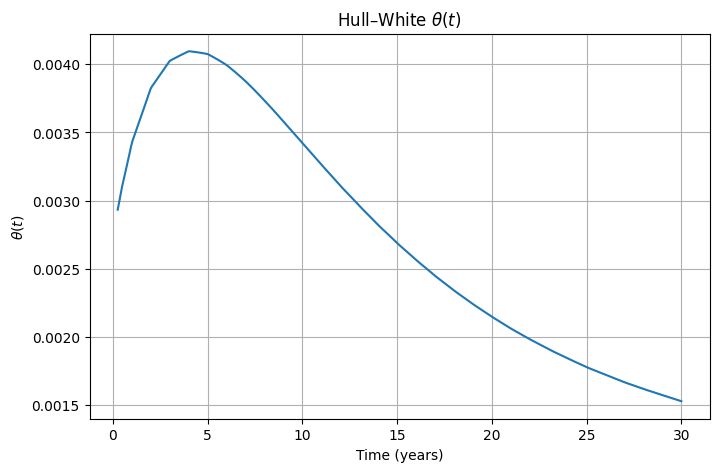


Estimates of Hull-White parameters: alpha=0.0614, sigma=0.0060


In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline

def estimate_hull_white(df, a_vasicek, sigma_vasicek, b_vasicek, yield_curve_df):
    # Prepare historical rates
    df = df.sort_values('DATE').copy()
    rates = df['RATE'].values / 100  # Convert % to decimal
    dates = pd.to_datetime(df['DATE'])

    # Time in years from first observation
    times = ((dates - dates.iloc[0]).dt.days / 365.25).values

    # Use Vasicek estimates as initial guess
    alpha_guess = a_vasicek
    sigma_guess = sigma_vasicek

    # Negative log-likelihood (simplified: constant θ(t)/α ratio)
    def neg_logL(params):
        alpha, sigma = params[0], params[1]
        total = 0.0
        for i in range(1, len(rates)):
            dt = times[i] - times[i-1]

            # Use b_vasicek as proxy for constant θ/α ratio
            mu = rates[i-1] * np.exp(-alpha * dt) + b_vasicek * (1 - np.exp(-alpha * dt))
            var = sigma**2 / (2 * alpha) * (1 - np.exp(-2 * alpha * dt))
            total += 0.5 * np.log(2 * np.pi * var) + (rates[i] - mu)**2 / (2 * var)

        return total

    # Optimize for alpha, sigma
    result = minimize(neg_logL, [alpha_guess, sigma_guess], bounds=[(0.001, 5.0), (0.0001, 0.5)])
    alpha_hat, sigma_hat = result.x

    # Create spline for today's yield curve
    yield_curve_df = yield_curve_df.sort_values('YEARS')
    spline_logP = CubicSpline(yield_curve_df['YEARS'], np.log(yield_curve_df['DISCOUNT FACTOR']))

    def theta_func(t):
        d1 = spline_logP.derivative(1)(t)
        d2 = spline_logP.derivative(2)(t)
        f0t = -d1
        df0t_dt = -d2
        return df0t_dt + alpha_hat * f0t + (sigma_hat**2/(2*alpha_hat)) * (1 - np.exp(-2*alpha_hat*t))

    return alpha_hat, sigma_hat, theta_func

def plot_theta(T_min=0.25, T_max=30, n=500):
  t_grid = np.linspace(T_min, T_max, n)
  theta_values = theta(t_grid)

  plt.figure(figsize=(8, 5))
  plt.plot(t_grid, theta_values)
  plt.xlabel("Time (years)")
  plt.ylabel(r"$\theta(t)$")
  plt.title("Hull–White $\\theta(t)$")
  plt.grid(True)
  plt.show()

alpha, sigma_hw, theta = estimate_hull_white(euribor_rates_df, a, sigma_vasicek, b, yield_curve_df)
plot_theta()
print(f"\nEstimates of Hull-White parameters: alpha={alpha:.4f}, sigma={sigma_hw:.4f}")


### Simulated Short-Rate Curves
Using the discretizations for the Vasicek and Hull-White models presented in the section above, we can simulate paths of the interest rates in each model. The discretization of the Vasicek model can be expressed as

$$
r_{t+\Delta t}
=
r_t e^{-a \Delta t}
+
b \left(1 - e^{-a \Delta t}\right)
+
\sigma \sqrt{\frac{1 - e^{-2a \Delta t}}{2a}}\,Z_t,
\qquad
Z_t \sim N(0,1)
$$

and the discretization of the Hull-White model can be expressed as

$$
r_{t+\Delta t}
=
r_t e^{-\alpha \Delta t}
+
\int_t^{t+\Delta t}
e^{-\alpha (t+\Delta t - s)} \theta(s)\,ds
+
\sigma \sqrt{\frac{1 - e^{-2\alpha \Delta t}}{2\alpha}}\,Z_t,
\qquad
Z_t \sim \ N(0,1)
$$

Based on this, we can simulate paths of the future short rate under the two interest rate models, and use this to price different interest rate derivatives. The plot below shows five pairs of interest rates, with the same underlying simulation of the standard normal random variables for both models in each pair (each color).


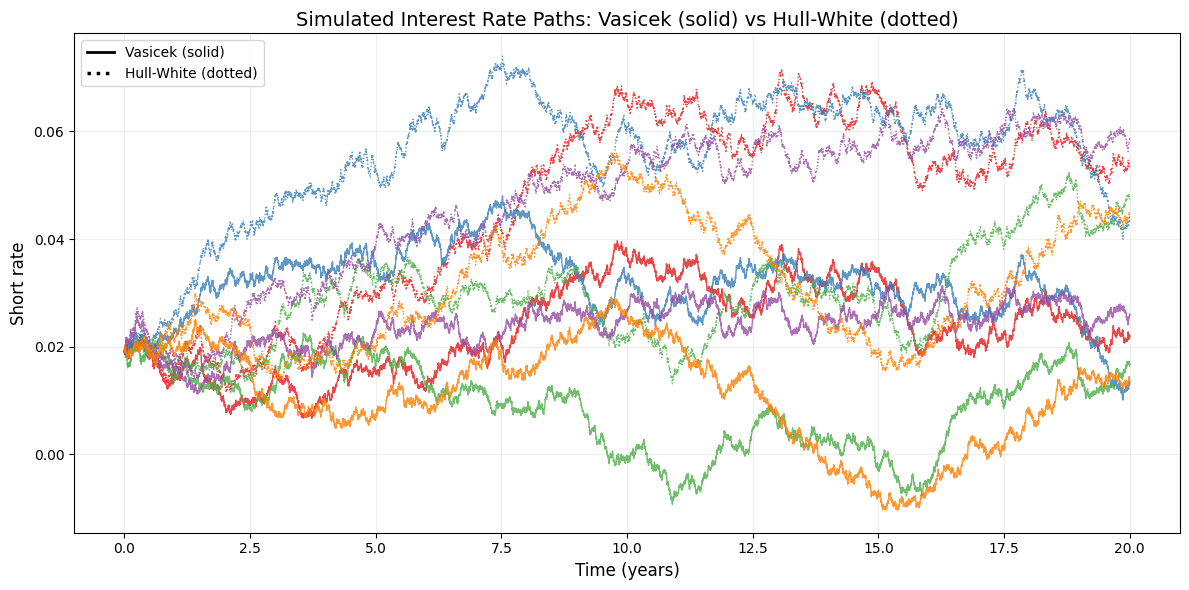

In [4]:
import numpy as np
from matplotlib.lines import Line2D
np.random.seed(123)

def simulate_standard_normals(N):
    return np.random.normal(0.0, 1.0, size=N)

def simulate_vasicek(r0, T, N, a, b, sigma_vasicek, Z):
    dt = T / N
    r = np.zeros(N + 1)
    r[0] = r0

    exp_a = np.exp(-a * dt)
    variance = sigma_vasicek**2 * (1 - np.exp(-2 * a * dt)) / (2 * a)
    std = np.sqrt(variance)

    for i in range(N):
        r[i+1] = r[i] * exp_a + b * (1 - exp_a) + std * Z[i]

    return r

def simulate_hull_white(r0, T, N, alpha, sigma_hw, theta, Z):
    dt = T / N
    r = np.zeros(N + 1)
    r[0] = r0

    exp_alpha = np.exp(-alpha * dt)
    variance = sigma_hw**2 * (1 - np.exp(-2 * alpha * dt)) / (2 * alpha)
    std = np.sqrt(variance)

    for i in range(N):
        t = i * dt
        r[i+1] = r[i] * exp_alpha + (1 - exp_alpha) / alpha * theta(t) + std * Z[i] # the integral is approximated as dt is small

    return r

def plot_interest_rates(r0, T, N, M=5):
    np.random.seed(123)
    t = np.linspace(0, T, N + 1)
    plt.figure(figsize=(12, 6))
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']  # Red, Blue, Green, Purple, Orange

    for m in range(M):
        Z = simulate_standard_normals(N)

        rates_vasicek = simulate_vasicek(r0, T, N, a, b, sigma_vasicek, Z)
        rates_hw = simulate_hull_white(r0, T, N, alpha, sigma_hw, theta, Z)

        color = colors[m]
        plt.plot(t, rates_vasicek, color=color, linestyle='-', linewidth=1.0, alpha=0.8)
        plt.plot(t, rates_hw, color=color, linestyle=':', linewidth=1.0, alpha=0.8)

    plt.xlabel("Time (years)", fontsize=12)
    plt.ylabel("Short rate", fontsize=12)
    plt.title(f"Simulated Interest Rate Paths: Vasicek (solid) vs Hull-White (dotted)", fontsize=14)

    legend_elements = [
        Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Vasicek (solid)'),
        Line2D([0], [0], color='black', linestyle=':', linewidth=2.5, label='Hull-White (dotted)')]

    plt.legend(handles=legend_elements, fontsize=10, loc='best')

    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

r0 = euribor_rates_df['RATE'].iloc[-1] / 100
plot_interest_rates(r0, 20, 10_000)

In the plot above, we see that the Hull-White interest rates rise quickly in the beginning, in contrast to the interest rates in the Vasicek model. This is because of the function $θ(t)$ in the Hull-White model, which rises quickly for the first few years, and then decreases. The Vasicek model, on the other hand, tends to revert to the long-term mean interest rate over time. The phenomenon of the Hull-White model predicting higher interest rates than the Vasicek model is a consequence of the estimated parameters; it is not necessarily the case that the Hull-White model generally predicts higher rates than the Vasicek model.

We can also investigate the distribution of the simulated future short rates in the Hull-White and Vasicek models for a given maturity. In the histogram below, the same standard normal random variables are used for both interest rate models, similarly to what is done in the plot above, allowing a reasonable comparison between the two interest rate models.

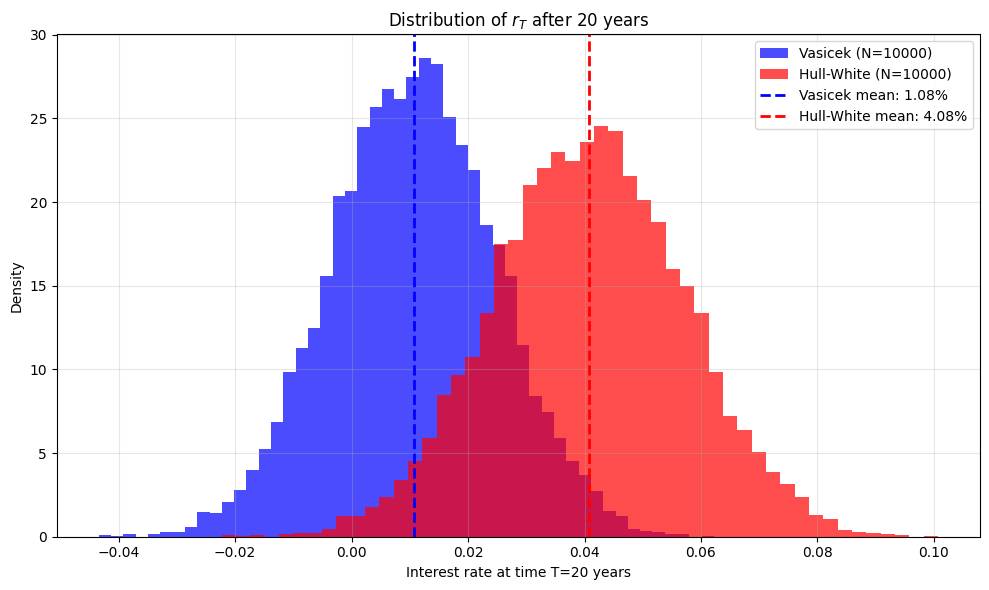

In [5]:
def plot_rate_histograms_T(r0, T, a, b, sigma_vasicek, alpha, sigma_hw, theta, N_simulations=10000):
    vasicek_rates_T = np.zeros(N_simulations)
    hullwhite_rates_T = np.zeros(N_simulations)

    for i in range(N_simulations):
        Z = np.random.normal(0, 1)

        mu_V = r0 * np.exp(-a * T) + b * (1 - np.exp(-a * T))
        std_V = sigma_vasicek * np.sqrt((1 - np.exp(-2 * a * T)) / (2 * a))
        vasicek_rates_T[i] = mu_V + std_V * Z

        u_vals = np.linspace(0, T, 100)
        integrand = np.exp(-alpha * (T - u_vals)) * np.vectorize(theta)(u_vals)
        mu_HW = r0 * np.exp(-alpha * T) + np.trapezoid(integrand, u_vals)
        std_HW = sigma_hw * np.sqrt((1 - np.exp(-2 * alpha * T)) / (2 * alpha))
        hullwhite_rates_T[i] = mu_HW + std_HW * Z

    plt.figure(figsize=(10, 6))

    all_rates = np.concatenate([vasicek_rates_T, hullwhite_rates_T])
    n_bins = 50

    plt.hist(vasicek_rates_T, bins=n_bins, alpha=0.7, color='blue', label=f'Vasicek (N={N_simulations})', density=True)
    plt.hist(hullwhite_rates_T, bins=n_bins, alpha=0.7, color='red', label=f'Hull-White (N={N_simulations})', density=True)

    plt.axvline(mu_V, color='blue', linestyle='--', linewidth=2, label=f'Vasicek mean: {mu_V*100:.2f}%')
    plt.axvline(mu_HW, color='red', linestyle='--', linewidth=2, label=f'Hull-White mean: {mu_HW*100:.2f}%')

    plt.xlabel(f'Interest rate at time T={T} years')
    plt.ylabel('Density')
    plt.title(f'Distribution of $r_T$ after {T} years')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rate_histograms_T(r0, 20, a, b, sigma_vasicek, alpha, sigma_hw, theta)


In the histogram above, we see that, just like the simulated paths above, the Hull-White model predicts higher future short rates than the Vasicek model. Both models predict interest rates that are normally distributed around a mean, which, in general is higher for the Hull-White model, though the mean in the Hull-White model is time-dependent, as the drift adjustment function $\theta(t)$ is time-dependent.

### Comparison of the Vasicek and Hull-White Models
The Vasicek and Hull-White models are both short-rate models, meaning that they describe the instantaneous short rate, rather than modelling the prices of longer-maturity bonds. Despite this, the two models differ in several aspects.

The Vasicek model has constant parameters $a$, $b$, and $\sigma$,

$$dr_t=a(b-r_t)\,dt+\sigma\,dW_t$$

where the short rate is mean-reverting towards the constant long-run level $b$. The Hull-White model can be seen as an extension of the Vasicek model, as it allows the drift to vary over time,

$$dr_t=(\theta(t)-\alpha r_t)\,dt+\sigma\,dW_t$$

where the function $\theta(t)$ can be chosen to fit the observed initial term structure. The fact that the current term structure can be captured exactly by the Hull-White model is one of its main advantages, but it can also be seen as a disadvantage, since it requires determining the function $\theta(t)$.

Though the short rate given in each model is stochastic, each implies a (deterministic) zero-coupon bond price at the present time $t=0$. For a zero-coupon bond maturing at time $T$, the model-implied price is the expected discounted value of one unit paid at maturity,

$$P(0,T)=\mathbb{E}^{\mathbb{Q}}\left[\exp\left(-\int_0^T r_s\,ds\right)\right]$$

Consequently, as we will see in the zero-coupon bond pricing below, each model produces a zero-coupon bond price for every maturity $T$. This can be converted into a continuously compounded spot yield using

$$y(0,T)=-\frac{\ln P(0,T)}{T}$$

This gives a model-implied yield curve.

For the Vasicek model, the parameters $a$, $b$ and $\sigma$ are estimated from historical data. As these parameters are constant, the resulting model-implied yield curve is determined by the historical dynamics of the short rate and will generally not coincide with the current market yield curve.

A possible disadvantage of the Hull-White model is that, unlike the Vasicek model, its time-dependent function $\theta(t)$ is typically calibrated to the observed term structure, and therefore cannot be directly determined for times $T$ beyond the available market data. This could, for example, prevent it from pricing interest rate securities with very long maturities. At the other hand, this problem can be overcome by extrapolating the function $\theta(t)$ to the region where it is not determined by the term structure. Furthermore, using the Vasicek model to price such interest rate securities can also be problematic, as it assumes that the constants $a$ and $b$ are constant over time, which is likely not a very realistic assumption.

Another limitation, which applied to both models, is the assumption of a constant volatility $σ$, which is not entirely realistic. Furthermore, both interest rate models allow the modelled short rates to become negative. Despite these disadvantages, the two models are commonly used thanks to their desirable characteristics, like closed-form ZCB pricing formulas.

### Zero-Coupon Bond Pricing
An advantage of both the Vasicek and Hull-White model is that they have closed-form expressions for the price of zero-coupon bonds (ZCBs). For the Vasicek model, the price $P(t,T)$ at time $t$ for the price of a ZCB with face value $1$ and maturity at time $T$ is

$$
P(t, T) = A(t, T) e^{-B(t, T) r_t}
$$

where

$$
B(t, T) = \frac{1 - e^{-a(T-t)}}{a}
$$

and

$$
A(t, T) = \exp\left\{
\left(b - \frac{\sigma^2}{2a^2}\right)\left[B(t, T) - (T-t)\right]
- \frac{\sigma^2}{4a} B(t, T)^2
\right\}
$$

For the Hull-White model, the price is given by

$$
P(t, T) = \frac{P(0, T)}{P(0, t)}
\exp\left\{
-B(t, T)\left[r(t) - f(0, t)\right]
- \frac{\sigma^2}{4\alpha } B(t, T)^2 \left(1 - e^{-2\alpha t}\right)
\right\}
$$

where $B(t,T)$ is the same as for the Vasicek model (but with $\alpha$ replacing $a$), and

$$
f(0, t) = -\frac{d}{d t} \ln P(0, t)
$$

Interestingly, the price of a ZCB in the Hull-White model does not depend on the function $\theta(t)$.

### Zero-Coupon Bond Price Derivation
To see why this is the case, let us derive the formula for $P(t,T)$ for the Vasicek model. The SDE for the short rate $r_t$, under the risk-neutral measure $\mathbb{Q}$ for the Vasicek model is given by

$$
dr_t = a(b - r_t)dt + \sigma dW_t^\mathbb{Q}
$$

Assume the zero-coupon bond price has the affine form

$$
P(t,T) = A(t,T)e^{-B(t,T)r_t}
$$

with terminal condition $P(T,T) = 1$, which implies

$$
A(T,T) = 1, \quad B(T,T) = 0
$$

We define $f(t,r) = \ln(P(t,T)) = \ln(A(t,T)) - B(t,T)r_t$.
Applying  Itô's lemma to $f(t,r)$ gives

$$
df = \frac{\partial f}{\partial t}dt + \frac{\partial f}{\partial r}dr + \frac{1}{2}\frac{\partial^2 f}{\partial r^2}(dr)^2
$$

The partial derivatives are calculated as

$$
\begin{align*}
\frac{\partial f}{\partial t} &= \frac{A_t(t,T)}{A(t,T)} - B_t(t,T)r_t \\
\frac{\partial f}{\partial r} &= -B(t,T) \\
\frac{\partial^2 f}{\partial r^2} &= 0
\end{align*}
$$

where $A_t = \frac{\partial A}{\partial t}$, $B_t = \frac{\partial B}{\partial t}$ are partial derivatives.

Substituting $dr_t = a(b - r_t)dt + \sigma dW_t^\mathbb{Q}$ gives
\begin{align*}
df &= \left[\frac{A_t}{A} - B_t r_t - Ba(b - r_t)\right]dt - B\sigma dW_t^\mathbb{Q} \\
&= \left[\frac{A_t}{A} - a b B + (aB - B_t) r_t\right]dt - B\sigma dW_t^\mathbb{Q}
\end{align*}

Since $dP = P df + \frac{1}{2}P(df)^2$, and $(df)^2 = B^2\sigma^2 dt$ since $(dW^{\mathbb{Q}})^2 = dt$

$$
\begin{align*}
\frac{dP}{P} &= df + \frac{1}{2}B^2\sigma^2 dt \\
&= \left[\frac{A_t}{A} - a b B + (aB - B_t) r_t + \frac{1}{2}B^2\sigma^2\right]dt - B\sigma dW_t^\mathbb{Q}
\end{align*}
$$

Under $\mathbb{Q}$, the discounted bond price $\tilde{P}(t,T) = e^{-\int_0^t r_s ds}P(t,T)$ must be a martingale.
By Itô's product rule,

$$
d\tilde{P} = e^{-\int_0^t r_s ds}(dP - r_t P dt)
$$

For $\tilde{P}$ to be a martingale, the drift must be zero, translating to the condition that

$$
\frac{A_t}{A} - a b B + (aB - B_t) r_t + \frac{1}{2}B^2\sigma^2 - r_t = 0
$$

Or, equivalently,

$$
\frac{A_t}{A} - a b B + \frac{1}{2}B^2\sigma^2 + (aB - B_t - 1) r_t = 0
$$

Since this must hold for all values of $r_t$, we obtain two ODEs:

\begin{align}
aB(t,T) - B_t(t,T) - 1 &= 0 \\
\frac{A_t(t,T)}{A(t,T)} - a b B(t,T) + \frac{1}{2}\sigma^2 B(t,T)^2 &= 0
\end{align}

With boundary conditions $B(T,T) = 0$ and $A(T,T) = 1$.

For the first of the two equations above, we get that

$$
\frac{dB}{dt} = aB - 1
$$

This is a linear first-order ODE, and with $B(T,T)=0$, the solution is

$$
B(t,T) = \frac{1 - e^{-a(T-t)}}{a}
$$

For the second of the two equations, we get that

$$
\frac{d}{dt}\ln A(t,T) = a b B(t,T) - \frac{1}{2}\sigma^2 B(t,T)^2
$$

Integrating from $t$ to $T$ and using $A(T,T)=1$ gives

$$
\ln A(t,T) = \int_t^T \left[ a b B(s,T) - \frac{1}{2}\sigma^2 B(s,T)^2 \right] ds
$$

Substituting $B(s,T) = \frac{1 - e^{-a(T-s)}}{a}$ and evaluating the integrals yields
$$
A(t,T) = \exp\left\{\left(b - \frac{\sigma^2}{2a^2}\right)[B(t,T) - (T-t)] - \frac{\sigma^2}{4a}B(t,T)^2\right\}
$$

Hence, we arrive at the formula for a zero-coupon bond price in the Vasicek model:
$$
\boxed{P(t,T) = A(t,T)e^{-B(t,T)r_t}}
$$

with

$$
\boxed{B(t,T) = \frac{1 - e^{-a(T-t)}}{a}}
$$

and

$$
\boxed{A(t,T) = \exp\left\{\left(b - \frac{\sigma^2}{2a^2}\right)[B(t,T) - (T-t)] - \frac{\sigma^2}{4a}B(t,T)^2\right\}}
$$

The derivation of $P(t,T)$ in the Hull-White model is similar.


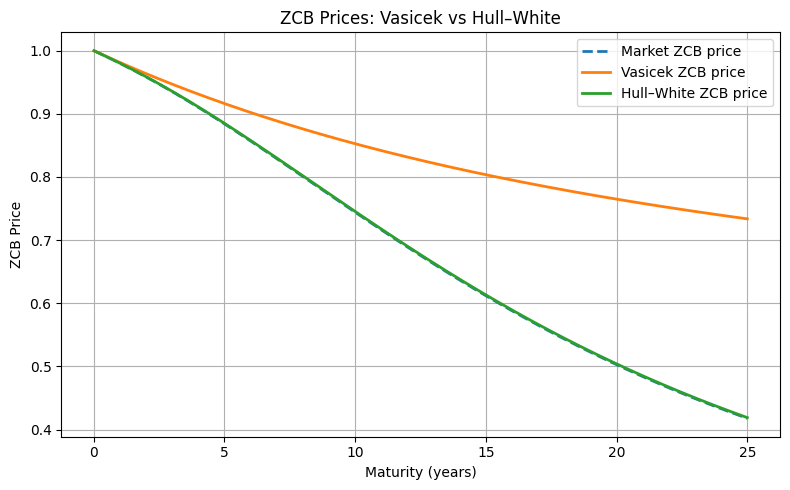

In [6]:
def vasicek_zcb_price(t, T, r_t, a, b, sigma):
    tau = T - t
    B = (1 - np.exp(-a * tau)) / a
    A = np.exp((b - sigma**2/(2*a**2)) * (B - tau) - (sigma**2/(4*a)) * B**2)
    return A * np.exp(-B * r_t)

def hullwhite_zcb_price(t, T, r_t, a, sigma, discount_curve):
    P0_T = discount_curve(T)  # P(0, T)
    P0_t = discount_curve(t)  # P(0, t)

    # B(t, T) function (same as Vasicek)
    tau = T - t
    B = (1 - np.exp(-a * tau)) / a

    # Forward rate f(0, t) = -∂/∂t ln P(0, t) by numerical derivative
    dt = 1e-5
    f0t = -(np.log(discount_curve(t + dt)) - np.log(discount_curve(t))) / dt

    # Compute A(t, T)
    A = (P0_T / P0_t) * np.exp(B * f0t - (sigma**2/(4*a)) * B**2 * (1 - np.exp(-2*a*t)))

    return A * np.exp(-B * r_t)

def plot_zcb_prices(T_max, n_points, r0, a, b, sigma_vas, sigma_hw, discount_curve):
    t = 0.0
    T_grid = np.linspace(0.01, T_max, n_points)

    mkt_prices = [discount_curve(T) for T in T_grid]
    vas_prices = [vasicek_zcb_price(t, T, r0, a, b, sigma_vas) for T in T_grid]
    hw_prices = [hullwhite_zcb_price(t, T, r0, a, sigma_hw, discount_curve) for T in T_grid]

    plt.figure(figsize=(8, 5))
    plt.plot(T_grid, mkt_prices, label="Market ZCB price", linewidth=2, linestyle = "--")
    plt.plot(T_grid, vas_prices, label="Vasicek ZCB price", linewidth=2)
    plt.plot(T_grid, hw_prices, label="Hull–White ZCB price", linewidth=2)

    plt.xlabel("Maturity (years)")
    plt.ylabel("ZCB Price")
    plt.title("ZCB Prices: Vasicek vs Hull–White")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_zcb_prices(25, 10_000, r0, a, b, sigma_vasicek, sigma_hw, discount_curve)

In the graph above, we see that the Hull-White model of interest rates overlaps almost exactly with the market prices (discount factors). This is in line with what is expected - we fit the function $θ(t)$ so that the Hull-White interest rates match the interest rates of the yield curve exactly, making the Hull-White ZCB prices the same as the market prices. As the Vasicek model cannot be fitted exactly to the yield curve, it does not produce the same ZCB prices as the market, and in this case, it prices these ZCBs higher than the market, as it has a single long-term average interest rate, toward which it reverts. It should also be mentioned that the Vasicek price of the ZCBs depends on the parameters, which are here estimated under the real-world measure, rather than the risk-neutral measure under which pricing is done, so there may be a slight discrepancy between these parameters.

### Interest Rate Cap Pricing
Having derived the prices of zero-coupon bonds under both the Vasicek and Hull-White models, these bond prices can be used to price interest rate caps. The main advantage of these models is that the price of a cap can be expressed as a series of options on zero-coupon bonds, for which closed-form solutions exist, as shown above.

Consider an interest rate cap with notional $N$, strike rate $K$, and reset dates

$$0=T_0 < T_1 < \dots < T_n$$

Let the length of each accrual period be

$$\delta_i=T_i-T_{i-1}$$

The cap consists of a series of so-called 'caplets', with the $i$:th caplet pays, at time $T_i$, the amount

$$N\delta_i \max(L(T_{i-1},T_i)-K,0)$$

where $L(T_{i-1},T_i)$ is the interest rate observed at time $T_{i-1}$ for the period from $T_{i-1}$ to $T_i$. Using the relation between the forward rate and the zero-coupon bond price

$$L(T_{i-1},T_i)=\frac{1}{\delta_i}\left(\frac{1}{P(T_{i-1},T_i)}-1\right)$$

the caplet payoff can be written as

$$\frac{1}{P(T_{i-1},T_i)} N\max\left(1-(1+K\delta_i)P(T_{i-1},T_i),0\right)$$

Since $P(T_{i-1},T_i)$ is the price at time $T_{i-1}$ of a zero-coupon bond with maturity at $T_i$ and face value $1$, $P(T_{i-1},T_i)$ is the discount factor from $T_{i-1}$ to $T_i$, and the value of the caplet at $T_{i-1}$ is thus the payoff above, multiplied by $P(T_{i-1},T_i)$. Thus, the value at $T_{i-1}$ of the caplet's payoff at $T_i$, is

$$N\max\left(1-(1+K\delta_i)P(T_{i-1},T_i),0\right)$$

or, equivalently,

$$N (1+K\delta_i) \max\left(\frac{1}{1+K\delta_i}-P(T_{i-1},T_i),0\right)$$


Thus, at time $T_{i-1}$, the value of the caplet can be thought of as the payoff from a put option on a zero-coupon bond maturing at $T_i$, with strike

$$K_{B,i}=\frac{1}{1+K\delta_i}$$

Now, to price the interest rate cap, we calculate the present value of the sum of the caplets.

As above, the price of a ZCB under the Vasicek model is

$$P(t, T) = A(t, T) e^{-B(t, T) r_t}$$

where

$$B(t, T) = \frac{1 - e^{-a(T-t)}}{a}$$

and

$$A(t, T) = \exp\left\{\left(b - \frac{\sigma^2}{2a^2}\right)\left[B(t, T) - (T-t)\right]- \frac{\sigma^2}{4a} B(t, T)^2\right\}$$

while for the Hull-White model, the price is

$$P(t, T) = \frac{P(0, T)}{P(0, t)}\exp\left\{-B(t, T)\left[r(t) - f(0, t)\right]- \frac{\sigma^2}{4\alpha } B(t, T)^2 \left(1 - e^{-2\alpha  t}\right)\right\}$$

with $B(t,T)$ as in the Vasicek model (with $\alpha$ instead of $a$), and

$$f(0, t) = -\frac{d}{d t} \ln P(0, t)$$

Because bond prices are lognormally distributed under both the Vasicek and the Hull-White model, Jamshidian's (1989) formula gives the caplet price as:

$$\text{Caplet}_i(0) = N(1 + \delta_i K) \Big[ K^* p(0, T_{i-1}) \Phi(-h_{2,i}) - p(0, T_i) \Phi(-h_{1,i}) \Big]$$

where:

$$h_{1,i} = \frac{\ln\left(\frac{p(0, T_i)}{p(0, T_{i-1}) K^*}\right) + \frac{1}{2} \sigma_{P,i}^2}{\sigma_{P,i}}$$

$$h_{2,i} = h_{1,i} - \sigma_{P,i}$$

For the Vasicek model,
$$\sigma_{P, i} = \sigma \sqrt{\frac{1 - e^{-2a T_{i-1}}}{2a}} \cdot B(T_{i-1}, T_i)$$

For the Hull-White model,
$$\sigma_{P, i} = \sigma \sqrt{\frac{1 - e^{-2\alpha T_{i-1}}}{2α}} \cdot B(T_{i-1}, T_i)$$

and where

$$K^* = \frac{1}{1 + \delta_i K}$$

The only difference in the price of the interest rate cap, between the Vasicek and the Hull-White models, is the values of the ZCB pricing formulas used in the interest rate cap price, as well as the parameters varying between the models.




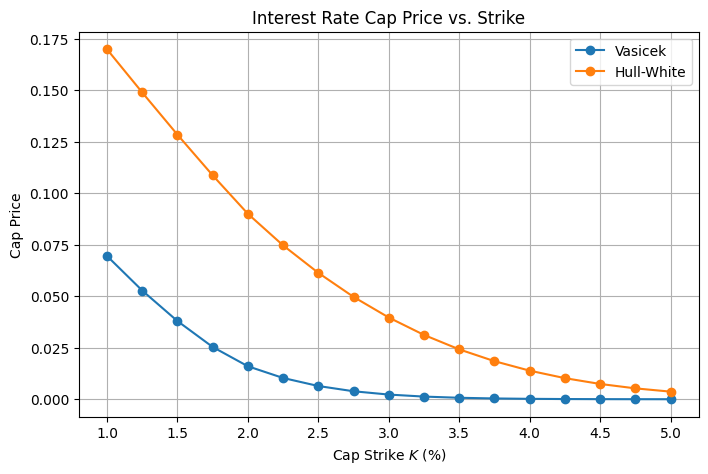

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def caplet_bond_volatility(T_i_minus_1, T_i, a, sigma):
    delta = T_i - T_i_minus_1
    return (sigma / a * (1 - np.exp(-a * delta)) * np.sqrt((1 - np.exp(-2 * a * T_i_minus_1)) / (2 * a)))

def vasicek_cap_price(r0, a, b, sigma, T, K, N, n_caplets):
    delta = T / n_caplets
    cap_price = 0.0

    for i in range(1, n_caplets + 1):
        T_i_minus_1 = (i - 1) * delta
        T_i = i * delta

        # ZCB prices at time 0
        P_i_minus_1 = vasicek_zcb_price(0, T_i_minus_1, r0, a, b, sigma)
        P_i = vasicek_zcb_price(0, T_i, r0, a, b, sigma)

        # First caplet: fixing occurs at t = 0
        if i == 1:
            caplet_price = N * max(1 - (1 + delta * K) * P_i, 0)

        else:
            K_star = 1 / (1 + delta * K)
            sigma_P = caplet_bond_volatility(T_i_minus_1, T_i, a, sigma)
            h1 = (np.log(P_i / (P_i_minus_1 * K_star)) + 0.5 * sigma_P**2) / sigma_P
            h2 = h1 - sigma_P
            caplet_price = (N * (1 + delta * K) * (K_star * P_i_minus_1 * norm.cdf(-h2) - P_i * norm.cdf(-h1)))
        cap_price += caplet_price

    return cap_price


def hullwhite_cap_price(a, sigma, discount_curve, T, K, N, n_caplets):
    delta = T / n_caplets
    cap_price = 0.0

    for i in range(1, n_caplets + 1):
        T_i_minus_1 = (i - 1) * delta
        T_i = i * delta

        # Time-0 ZCB prices
        P_i_minus_1 = discount_curve(T_i_minus_1)
        P_i = discount_curve(T_i)

        # First caplet: fixing occurs at t = 0
        if i == 1:
            caplet_price = N * max(1 - (1 + delta * K) * P_i, 0)

        else:
            K_star = 1 / (1 + delta * K)
            sigma_P = caplet_bond_volatility(T_i_minus_1, T_i, a, sigma)
            h1 = (np.log(P_i / (P_i_minus_1 * K_star)) + 0.5 * sigma_P**2) / sigma_P
            h2 = h1 - sigma_P
            caplet_price = (N * (1 + delta * K) * (K_star * P_i_minus_1 * norm.cdf(-h2) - P_i * norm.cdf(-h1)))
        cap_price += caplet_price

    return cap_price

def plot_cap_price_vs_strike(r0_v, a_v, b_v, sigma_v, a_hw, sigma_hw, discount_curve, T, N, n_caplets, K_values):
    vasicek_prices = []
    hullwhite_prices = []

    for K in K_values:
        price_v = vasicek_cap_price(r0_v, a_v, b_v, sigma_v, T, K, N, n_caplets)
        price_hw = hullwhite_cap_price(a_hw, sigma_hw, discount_curve, T, K, N, n_caplets)
        vasicek_prices.append(price_v)
        hullwhite_prices.append(price_hw)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(K_values*100, vasicek_prices, marker='o', label="Vasicek")
    plt.plot(K_values*100, hullwhite_prices, marker='o', label="Hull-White")

    plt.xlabel("Cap Strike $K$ (%)")
    plt.ylabel("Cap Price")
    plt.title("Interest Rate Cap Price vs. Strike")
    plt.legend()
    plt.grid(True)
    plt.show()

    return (np.array(K_values),  np.array(vasicek_prices),  np.array(hullwhite_prices))

K_values = np.linspace(0.01, 0.05, 17)
K_values, prices_v, prices_hw = plot_cap_price_vs_strike(r0, a, b, sigma_vasicek, alpha, sigma_hw, discount_curve, 10, 1, 10, K_values)


In the plot above, we see that the Hull-White model estimates significantly higher prices for interest rate caps for the different values of the cap strike price $K$. This is not very surprising: as we saw in the previous sections, the Hull-White model predicts much higher rates than the Vasicek model does, increasing the model's price of the cap. We also see that the prices of the cap decrease as the strike price increases, just as it does for call options on stocks. Given that the Hull-White model is constructed to fit the current yield curve, the prices of the interest rate caps predicted by the Hull-White model are likely closer to the market prices of these interest rate derivatives than the prices predicted by the Vasicek model. However, though the Hull-White model reproduces the current yield curve, the cap prices will also depend on the  volatility, so matching the yield curve alone does not guarantee that its option prices coincide with the market prices.

Below, we compare these analytical values of the prices of the cap with the Monte Carlo simulations of the price, to illustrate the two methods of pricing the interest rate cap.

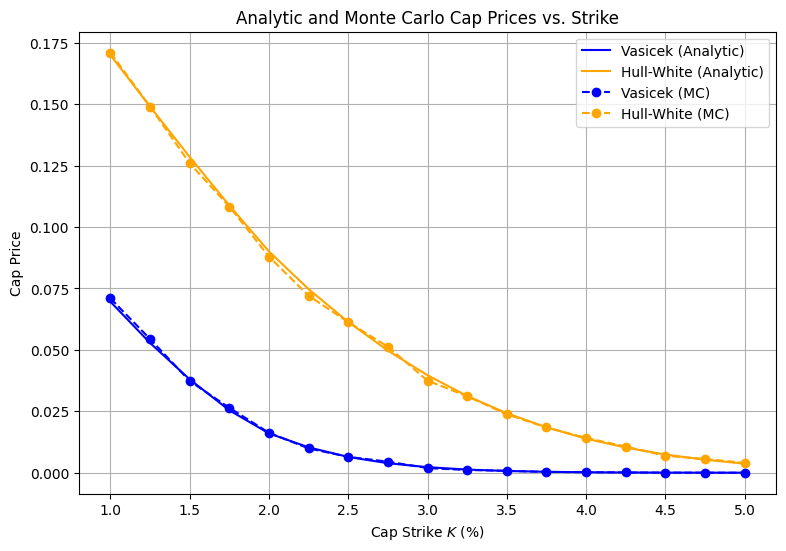

In [8]:
def compare_cap_mc_vasicek_hullwhite(r0_v, a_vasicek, b_vasicek, sigma_vasicek, alpha_hw, sigma_hw, theta, discount_curve, T, N, K, n_caplets, n_steps, n_paths):
    dt = T / n_steps
    delta = T / n_caplets

    steps_per_caplet = n_steps / n_caplets
    steps_per_caplet = int(steps_per_caplet)

    caplet_indices = np.arange(steps_per_caplet, n_steps + 1, steps_per_caplet)
    reset_indices = caplet_indices - steps_per_caplet

    vasicek_payoffs = np.zeros(n_paths)
    hullwhite_payoffs = np.zeros(n_paths)

    # Use the same random numbers for both models
    Z_all = np.random.normal(0.0, 1.0, size=(n_paths, n_steps))

    for j in range(n_paths):
        Z = Z_all[j]

        r_v = simulate_vasicek(r0, T, n_steps, a_vasicek, b_vasicek, sigma_vasicek, Z)
        r_hw = simulate_hull_white(r0, T, n_steps, alpha_hw, sigma_hw, theta, Z)

        # Discount factors along each path
        integral_v = np.zeros(n_steps + 1)
        integral_hw = np.zeros(n_steps + 1)

        integral_v[1:] = np.cumsum(0.5 * (r_v[:-1] + r_v[1:]) * dt)
        integral_hw[1:] = np.cumsum(0.5 * (r_hw[:-1] + r_hw[1:]) * dt)

        path_cap_v = 0.0
        path_cap_hw = 0.0

        for reset_idx, payment_idx in zip(reset_indices, caplet_indices):
            T_i_minus_1 = reset_idx * dt
            T_i = payment_idx * dt

            # Vasicek caplet
            P_v = vasicek_zcb_price(T_i_minus_1, T_i, r_v[reset_idx], a_vasicek, b_vasicek, sigma_vasicek)
            L_v = (1 / delta) * (1 / P_v - 1)
            payoff_v = N * delta * max(L_v - K, 0)
            discount_v = np.exp(-integral_v[payment_idx])
            path_cap_v += discount_v * payoff_v

            # Hull-White caplet
            P_hw = hullwhite_zcb_price(T_i_minus_1, T_i, r_hw[reset_idx], alpha_hw, sigma_hw, discount_curve)
            L_hw = (1 / delta) * (1 / P_hw - 1)
            payoff_hw = N * delta * max(L_hw - K, 0)
            discount_hw = np.exp(-integral_hw[payment_idx])
            path_cap_hw += discount_hw * payoff_hw

        vasicek_payoffs[j] = path_cap_v
        hullwhite_payoffs[j] = path_cap_hw

    vasicek_price = np.mean(vasicek_payoffs)
    hullwhite_price = np.mean(hullwhite_payoffs)

    return vasicek_price, hullwhite_price

def plot_cap_price_vs_strike_mc(r0_v, a_v, b_v, sigma_v, a_hw, sigma_hw, theta, discount_curve, T, N, n_caplets, n_steps, n_paths, K_values):
    vasicek_analytic = []
    hullwhite_analytic = []
    vasicek_mc = []
    hullwhite_mc = []

    for K in K_values:
        # Analytical prices
        price_v = vasicek_cap_price(r0_v, a_v, b_v, sigma_v, T, K, N, n_caplets)
        price_hw = hullwhite_cap_price(a_hw, sigma_hw, discount_curve, T, K, N, n_caplets)

        vasicek_analytic.append(price_v)
        hullwhite_analytic.append(price_hw)

        # Monte Carlo prices
        mc_v, mc_hw = compare_cap_mc_vasicek_hullwhite(r0_v, a_v, b_v, sigma_v, a_hw, sigma_hw, theta, discount_curve, T, N, K, n_caplets, n_steps, n_paths)

        vasicek_mc.append(mc_v)
        hullwhite_mc.append(mc_hw)

    # Plot
    plt.figure(figsize=(9, 6))

    plt.plot(K_values * 100, vasicek_analytic, color="blue", label="Vasicek (Analytic)")
    plt.plot(K_values * 100, hullwhite_analytic, color="orange", label="Hull-White (Analytic)")
    plt.plot(K_values * 100, vasicek_mc, marker='o', linestyle='--', color="blue", label="Vasicek (MC)")
    plt.plot(K_values * 100, hullwhite_mc, marker='o', linestyle='--', color="orange", label="Hull-White (MC)")

    plt.xlabel("Cap Strike $K$ (%)")
    plt.ylabel("Cap Price")
    plt.title("Analytic and Monte Carlo Cap Prices vs. Strike")
    plt.legend()
    plt.grid(True)
    plt.show()

vasicek_mc, hw_mc = compare_cap_mc_vasicek_hullwhite(r0, a, b, sigma_vasicek, alpha, sigma_hw, theta, discount_curve, 10, 1, 0.04, 10, 100, 1000)
results = plot_cap_price_vs_strike_mc(r0, a, b, sigma_vasicek, alpha, sigma_hw, theta, discount_curve, 10, 1, 10, 100, 1000, K_values)


As we see in the plot above, the Monte Carlo estimates of the price of the cap is similar to the analytical price, for both the Vasicek and Hull-White model of the short rate, but the estimated prices differ slightly from the analytical prices due to randomness; increasing the number of simulations decreases this.

### Interest Rate Swap Pricing under the Hull-White model
These ZCB prices can be used in pricing interest rate swaps, a common interest rate derivative. To price interest rate swaps, we must use the Hull-White model, as the Vasicek model's interest rates do not match the market rates, unlike the Hull-White model. An interest rate swap is a derivative where one pays a fixed interest rate and receives the floating rate, paid on the same notional amount, and the other party receives the fixed rate and pays the floating rate. The fixed interest rate $r$ is chosen so as to set the price of the interest rate swap to $0$ at time $t=0$. Hence $r$ is given as

$$
r = \frac{1 - P(0, t_n)}{\sum_{i=1}^n δ_i P(0, t_i)}
$$

where $P(0, t_i)$ is the price of a ZCB at time $t_i$, and $δ_i$ is the time (in years) between the payment dates. Let us consider the case of an interest rate swap that has annual payment dates for the coming $T$ years. The values of the fixed interest rate $r$ that this results in are shown in the plot below. As the Hull-White model rates are the same as the market rates, the pricing of this interest rate swap under the Hull-White model is the same as by using the observed market rates.


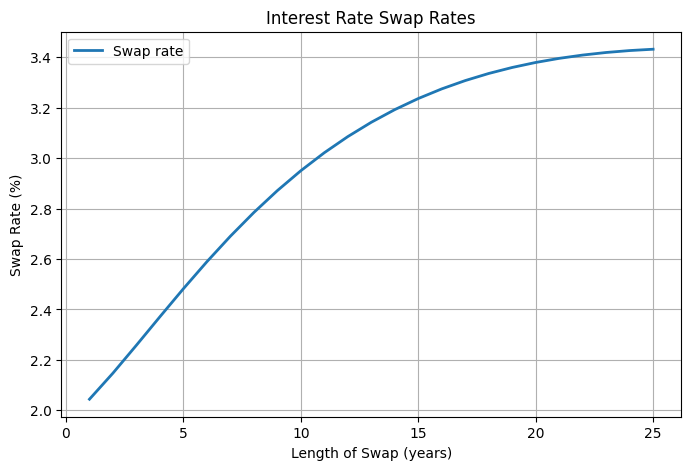

In [9]:
def swap_rate(maturities, deltas, discount_curve):
    P_values = [discount_curve(t) for t in maturities]
    numerator = 1 - P_values[-1]  # 1 - P(0, t_n)
    denominator = sum(dc * P for dc, P in zip(deltas, P_values))
    return numerator / denominator

def plot_swap_prices(T):
  t_grid = np.linspace(1, T, T)
  swap_rates = []
  for i in range(1, T+1):
      dates = np.linspace(1, i, i)
      deltas = np.linspace(1, 1, i)
      swap_rates.append(swap_rate(dates, deltas, discount_curve)*100)

  plt.figure(figsize=(8, 5))
  plt.plot(t_grid, swap_rates, label="Swap rate", linewidth=2)
  plt.xlabel("Length of Swap (years)")
  plt.ylabel("Swap Rate (%)")
  plt.title("Interest Rate Swap Rates")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_swap_prices(25)

In the plot above, we see that the swap rate increases as the number of years of which the swaps spans increases, but that the increase slows as the number of years increases. This is reasonable: the Hull-White (and market) interest rates increase as the maturity increases (ZCB prices decrease), increasing the fixed swap rate, but as the number of years becomes large, the rate converges to a long-run level, corresponding to the average of long-term forward rates

## Sources
Jamshidian, F. (1989). An Exact Bond Option Formula. The Journal of Finance, 44(1), 205-209. https://doi.org/10.2307/2328284https://www.jstor.org/stable/2328284